# Notebook 2 — OpenCV Basics

- each code cell starts with a **Parameters** section when relevant
- student exercises are marked with **STUDENT TASK**
- blanks to fill use `None` plus a `NotImplementedError`

Run the notebook from top to bottom.

This notebook focuses on a simple image-processing pipeline:

**capture/load → grayscale → blur → edges/threshold → contours → bounding boxes → live video**

In [1]:
# ============================================
# Setup
# Goal:
# Load the libraries used in the notebook.
# ============================================

# --- Parameters ---
# No parameters in this cell.

# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
import cv2
import time
from collections import deque

# --- Display helper ---
SHOW_AXES = False

Saved: ../images/captured_image.png


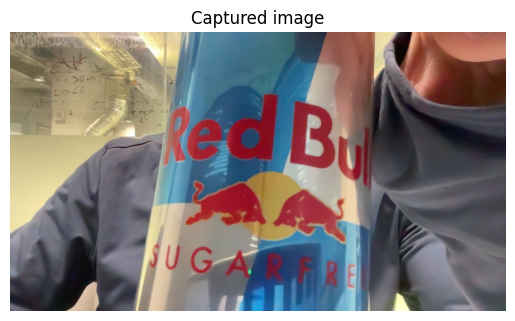

In [3]:
# ============================================
# Capture an image from your camera
# Goal:
# Take one picture using the default camera and save it for the rest of the notebook.
# ============================================

# --- Parameters ---
CAMERA_INDEX = 0
WARMUP_FRAMES = 20
SAVE_PATH = "../images/captured_image.png"
DISPLAY_TITLE = "Captured image"

# --- Camera capture ---
cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    ret = False
    frame = None

    for _ in range(WARMUP_FRAMES):
        ret, frame = cap.read()

    cap.release()

    if not ret:
        print("Failed to capture image.")
    else:
        cv2.imwrite(SAVE_PATH, frame)
        print("Saved:", SAVE_PATH)

        rgb_preview = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.imshow(rgb_preview)
        plt.title(DISPLAY_TITLE)
        plt.axis("on" if SHOW_AXES else "off")
        plt.show()

OpenCV loads images in BGR format (not RGB).
shape (H, W, C): (1080, 1920, 3)
dtype: uint8


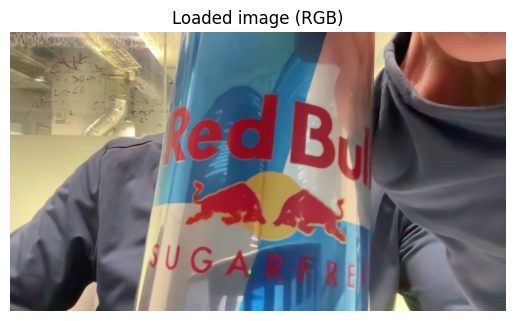

In [4]:
# ============================================
# Load a real image
# Goal:
# Understand how a color image is stored as a 3D array (H, W, C).
# ============================================

# --- Parameters ---
IMAGE_PATH = "../images/captured_image.png"
DISPLAY_TITLE = "Loaded image (RGB)"

# --- Load image ---
bgr = cv2.imread(IMAGE_PATH)

if bgr is None:
    raise FileNotFoundError(f"Couldn't load {IMAGE_PATH}. Make sure the file exists.")

print("OpenCV loads images in BGR format (not RGB).")
print("shape (H, W, C):", bgr.shape)
print("dtype:", bgr.dtype)

rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

plt.imshow(rgb)
plt.title(DISPLAY_TITLE)
plt.axis("on" if SHOW_AXES else "off")
plt.show()

In [5]:
# ============================================
# Example: inspect one pixel and one channel
# Goal:
# See how pixel values are stored in a color image.
# ============================================

# --- Parameters ---
TARGET_ROW = 100
TARGET_COL = 100
CHANNEL_NAMES = ["Red", "Green", "Blue"]

pixel_rgb = rgb[TARGET_ROW, TARGET_COL]
print(f"Pixel at ({TARGET_ROW}, {TARGET_COL}) in RGB:", pixel_rgb)

for i, name in enumerate(CHANNEL_NAMES):
    print(f"{name} value:", pixel_rgb[i])

Pixel at (100, 100) in RGB: [122 110  87]
Red value: 122
Green value: 110
Blue value: 87


shape: (1080, 1920)
dtype: uint8


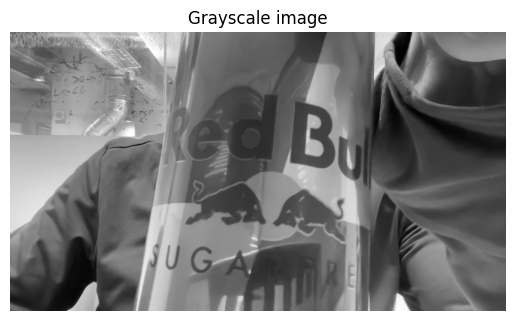

In [6]:
# ============================================
# Convert the image to grayscale
# Goal:
# See the difference between a color image and a 1-channel image.
# ============================================

# --- Parameters ---
DISPLAY_CMAP = "gray"
DISPLAY_TITLE = "Grayscale image"

gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

print("shape:", gray.shape)
print("dtype:", gray.dtype)

plt.imshow(gray, cmap=DISPLAY_CMAP)
plt.title(DISPLAY_TITLE)
plt.axis("on" if SHOW_AXES else "off")
plt.show()

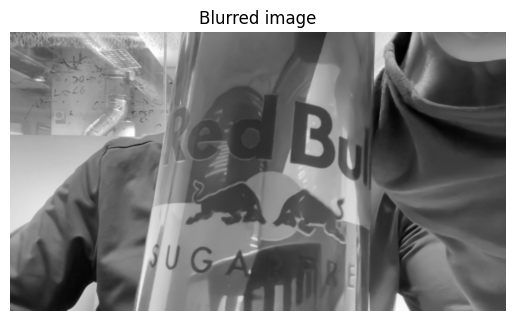

In [7]:
# ============================================
# Blur the grayscale image
# Goal:
# Smooth the image before edge detection or thresholding.
# ============================================

# --- Parameters ---
INPUT_IMAGE = gray
KERNEL_SIZE = (5, 5)
SIGMA_X = 0
DISPLAY_CMAP = "gray"
DISPLAY_TITLE = "Blurred image"

blur = cv2.GaussianBlur(INPUT_IMAGE, KERNEL_SIZE, SIGMA_X)

plt.imshow(blur, cmap=DISPLAY_CMAP)
plt.title(DISPLAY_TITLE)
plt.axis("on" if SHOW_AXES else "off")
plt.show()

In [8]:
# ============================================
# STUDENT TASK 1
# Goal:
# Try a stronger blur by changing the kernel size.
# ============================================

# --- Parameters ---
INPUT_IMAGE = gray
KERNEL_SIZE = None   # Example: (9, 9)
SIGMA_X = 0
DISPLAY_CMAP = "gray"
DISPLAY_TITLE = "Your blurred image"

if KERNEL_SIZE is None:
    raise NotImplementedError("Replace `None` with an odd kernel size such as (9, 9).")

your_blur = cv2.GaussianBlur(INPUT_IMAGE, KERNEL_SIZE, SIGMA_X)

plt.imshow(your_blur, cmap=DISPLAY_CMAP)
plt.title(DISPLAY_TITLE)
plt.axis("on" if SHOW_AXES else "off")
plt.show()

NotImplementedError: Replace `None` with an odd kernel size such as (9, 9).

shape: (1080, 1920)
dtype: uint8
unique values: [  0 255]


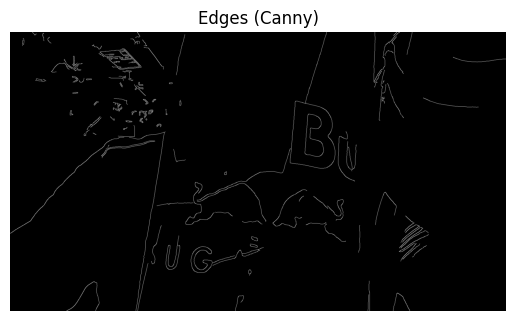

In [9]:
# ============================================
# Example: detect edges with Canny
# Goal:
# Identify strong intensity changes in the image.
# ============================================

# --- Parameters ---
INPUT_IMAGE = blur
LOW_THRESHOLD = 50
HIGH_THRESHOLD = 150
DISPLAY_CMAP = "gray"
DISPLAY_TITLE = "Edges (Canny)"

edges = cv2.Canny(INPUT_IMAGE, LOW_THRESHOLD, HIGH_THRESHOLD)

print("shape:", edges.shape)
print("dtype:", edges.dtype)
print("unique values:", np.unique(edges))

plt.imshow(edges, cmap=DISPLAY_CMAP)
plt.title(DISPLAY_TITLE)
plt.axis("on" if SHOW_AXES else "off")
plt.show()

In [10]:
# ============================================
# STUDENT TASK 2
# Goal:
# Choose thresholds that keep only the strongest edges.
# ============================================

# --- Parameters ---
INPUT_IMAGE = blur
LOW_THRESHOLD = None
HIGH_THRESHOLD = None
DISPLAY_CMAP = "gray"
DISPLAY_TITLE = "Edges (your version)"

if LOW_THRESHOLD is None or HIGH_THRESHOLD is None:
    raise NotImplementedError("Replace `None` with your thresholds before running this cell.")

your_edges = cv2.Canny(INPUT_IMAGE, LOW_THRESHOLD, HIGH_THRESHOLD)

print("unique values:", np.unique(your_edges))

plt.imshow(your_edges, cmap=DISPLAY_CMAP)
plt.title(DISPLAY_TITLE)
plt.axis("on" if SHOW_AXES else "off")
plt.show()

NotImplementedError: Replace `None` with your thresholds before running this cell.

## Live video example — Canny edges

In [11]:
# ============================================
# Live video: Canny edges
# Goal:
# Display edges from the camera in real time.
# ============================================

# --- Parameters ---
CAMERA_INDEX = 0
DISPLAY_SECONDS = 10
WINDOW_NAME = "Live Canny Edges"
LOW_THRESHOLD = 50
HIGH_THRESHOLD = 150
FRAME_DELAY_MS = 1

cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                print("Could not read frame.")
                break

            frame = cv2.flip(frame, 1)
            gray_live = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            blur_live = cv2.GaussianBlur(gray_live, (5, 5), 0)
            edges_live = cv2.Canny(blur_live, LOW_THRESHOLD, HIGH_THRESHOLD)

            cv2.imshow(WINDOW_NAME, edges_live)

            if time.time() - start_time > DISPLAY_SECONDS:
                break

            if cv2.waitKey(FRAME_DELAY_MS) & 0xFF == ord("q"):
                break

    finally:
        cap.release()
        cv2.waitKey(1)
        cv2.destroyAllWindows()
        cv2.waitKey(1)

shape: (1080, 1920)
dtype: uint8
unique values: [  0 255]


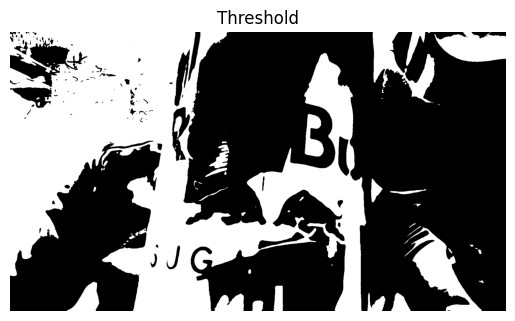

In [12]:
# ============================================
# Example: binary thresholding
# Goal:
# Convert a grayscale image into a black-and-white mask.
# ============================================

# --- Parameters ---
INPUT_IMAGE = blur
THRESHOLD_VALUE = 120
MAX_VALUE = 255
THRESHOLD_TYPE = cv2.THRESH_BINARY
DISPLAY_CMAP = "gray"
DISPLAY_TITLE = "Threshold"

_, thresh = cv2.threshold(INPUT_IMAGE, THRESHOLD_VALUE, MAX_VALUE, THRESHOLD_TYPE)

print("shape:", thresh.shape)
print("dtype:", thresh.dtype)
print("unique values:", np.unique(thresh))

plt.imshow(thresh, cmap=DISPLAY_CMAP)
plt.title(DISPLAY_TITLE)
plt.axis("on" if SHOW_AXES else "off")
plt.show()

In [13]:
# ============================================
# STUDENT TASK 3
# Goal:
# Adjust the threshold to isolate bright regions differently.
# ============================================

# --- Parameters ---
INPUT_IMAGE = blur
THRESHOLD_VALUE = None
MAX_VALUE = 255
THRESHOLD_TYPE = cv2.THRESH_BINARY
DISPLAY_CMAP = "gray"
DISPLAY_TITLE = "Threshold (your version)"

if THRESHOLD_VALUE is None:
    raise NotImplementedError("Replace `None` with a threshold value before running this cell.")

_, your_thresh = cv2.threshold(INPUT_IMAGE, THRESHOLD_VALUE, MAX_VALUE, THRESHOLD_TYPE)

plt.imshow(your_thresh, cmap=DISPLAY_CMAP)
plt.title(DISPLAY_TITLE)
plt.axis("on" if SHOW_AXES else "off")
plt.show()

NotImplementedError: Replace `None` with a threshold value before running this cell.

Contours found: 75


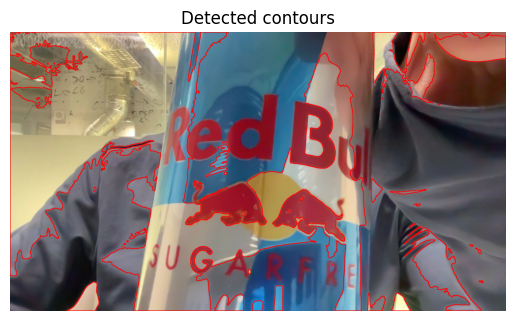

In [14]:
# ============================================
# Example: find and draw contours
# Goal:
# Detect object outlines from a binary image.
# ============================================

# --- Parameters ---
INPUT_BINARY_IMAGE = thresh
CONTOUR_RETRIEVAL_MODE = cv2.RETR_EXTERNAL
CONTOUR_APPROX_MODE = cv2.CHAIN_APPROX_SIMPLE
DRAW_COLOR = (255, 0, 0)   # red in RGB
DRAW_THICKNESS = 2
DISPLAY_TITLE = "Detected contours"

contours, _ = cv2.findContours(
    INPUT_BINARY_IMAGE,
    CONTOUR_RETRIEVAL_MODE,
    CONTOUR_APPROX_MODE
)

canvas = rgb.copy()
cv2.drawContours(canvas, contours, -1, DRAW_COLOR, DRAW_THICKNESS)

print("Contours found:", len(contours))

plt.imshow(canvas)
plt.title(DISPLAY_TITLE)
plt.axis("on" if SHOW_AXES else "off")
plt.show()

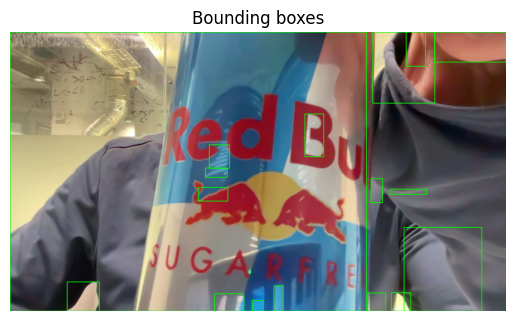

In [15]:
# ============================================
# Example: draw bounding boxes
# Goal:
# Enclose each detected object with a rectangle.
# ============================================

# --- Parameters ---
INPUT_IMAGE = rgb.copy()
RECTANGLE_COLOR = (0, 255, 0)   # green in RGB
RECTANGLE_THICKNESS = 2
MIN_AREA = 200
DISPLAY_TITLE = "Bounding boxes"

canvas = INPUT_IMAGE.copy()

for c in contours:
    if cv2.contourArea(c) < MIN_AREA:
        continue

    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(
        canvas,
        (x, y),
        (x + w, y + h),
        RECTANGLE_COLOR,
        RECTANGLE_THICKNESS,
    )

plt.imshow(canvas)
plt.title(DISPLAY_TITLE)
plt.axis("on" if SHOW_AXES else "off")
plt.show()

## Live video example — contours

In [18]:
# ============================================
# 📹 Live video: contours only
# Goal:
# Detect bright objects and draw their exact outlines
# ============================================

# --- Parameters ---
CAMERA_INDEX = 0
DISPLAY_SECONDS = 12
WINDOW_NAME = "Live Contours"

THRESHOLD_VALUE = 100
MIN_AREA = 500

CONTOUR_COLOR = (255, 0, 0)   # Blue (BGR)
CONTOUR_THICKNESS = 2

FRAME_DELAY_MS = 1

cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                print("Could not read frame.")
                break

            frame = cv2.flip(frame, 1)

            # --- Preprocessing ---
            gray_live = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            blur_live = cv2.GaussianBlur(gray_live, (5, 5), 0)
            _, thresh_live = cv2.threshold(
                blur_live,
                THRESHOLD_VALUE,
                255,
                cv2.THRESH_BINARY
            )

            # --- Find contours ---
            contours_live, _ = cv2.findContours(
                thresh_live,
                cv2.RETR_EXTERNAL,
                cv2.CHAIN_APPROX_SIMPLE
            )

            # --- Draw contours ---
            canvas = frame.copy()

            filtered_contours = [
                c for c in contours_live
                if cv2.contourArea(c) >= MIN_AREA
            ]

            cv2.drawContours(
                canvas,
                filtered_contours,
                -1,
                CONTOUR_COLOR,
                CONTOUR_THICKNESS
            )

            # --- Display ---
            cv2.imshow(WINDOW_NAME, canvas)

            # Stop after time
            if time.time() - start_time > DISPLAY_SECONDS:
                break

            if cv2.waitKey(FRAME_DELAY_MS) & 0xFF == ord("q"):
                break

    finally:
        cap.release()
        cv2.waitKey(1)
        cv2.destroyAllWindows()
        cv2.waitKey(1)

## Live video example — bounding boxes

In [17]:
# ============================================
# Live video: contours and bounding boxes
# Goal:
# Detect bright objects and draw one rectangle around each one.
# ============================================

# --- Parameters ---
CAMERA_INDEX = 0
DISPLAY_SECONDS = 12
WINDOW_NAME = "Live Bounding Boxes"
THRESHOLD_VALUE = 100
MIN_AREA = 500
RECTANGLE_COLOR = (0, 255, 0)   # green in BGR for OpenCV display
RECTANGLE_THICKNESS = 2
FRAME_DELAY_MS = 1

cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                print("Could not read frame.")
                break

            frame = cv2.flip(frame, 1)

            gray_live = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            blur_live = cv2.GaussianBlur(gray_live, (5, 5), 0)
            _, thresh_live = cv2.threshold(blur_live, THRESHOLD_VALUE, 255, cv2.THRESH_BINARY)

            contours_live, _ = cv2.findContours(
                thresh_live,
                cv2.RETR_EXTERNAL,
                cv2.CHAIN_APPROX_SIMPLE
            )

            canvas = frame.copy()

            for c in contours_live:
                if cv2.contourArea(c) < MIN_AREA:
                    continue

                x, y, w, h = cv2.boundingRect(c)
                cv2.rectangle(
                    canvas,
                    (x, y),
                    (x + w, y + h),
                    RECTANGLE_COLOR,
                    RECTANGLE_THICKNESS,
                )

            cv2.imshow(WINDOW_NAME, canvas)

            if time.time() - start_time > DISPLAY_SECONDS:
                break

            if cv2.waitKey(FRAME_DELAY_MS) & 0xFF == ord("q"):
                break

    finally:
        cap.release()
        cv2.waitKey(1)
        cv2.destroyAllWindows()
        cv2.waitKey(1)

##  Live video example  — motion trail

In [ ]:
# ============================================
# Live video: motion trail effect
# Goal:
# Keep a short fading trail mainly on moving regions.
# ============================================

# --- Parameters ---
CAMERA_INDEX = 0
DISPLAY_SECONDS = 10
WINDOW_NAME = "Motion Trail"
TRAIL_LENGTH = 10
THRESHOLD = 25
BLUR_SIZE = 7     # Must be odd
MIN_AREA = 500
FRAME_DELAY_MS = 1

cap = cv2.VideoCapture(CAMERA_INDEX)

if not cap.isOpened():
    print("Could not open camera.")
else:
    start_time = time.time()
    prev_gray = None
    trail_buffer = deque(maxlen=TRAIL_LENGTH)

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                print("Could not read frame from camera.")
                break

            frame = cv2.flip(frame, 1)
            display = frame.copy()

            gray_live = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            gray_live = cv2.GaussianBlur(gray_live, (BLUR_SIZE, BLUR_SIZE), 0)

            if prev_gray is not None:
                diff = cv2.absdiff(prev_gray, gray_live)
                _, motion_mask = cv2.threshold(diff, THRESHOLD, 255, cv2.THRESH_BINARY)

                kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
                motion_mask = cv2.morphologyEx(motion_mask, cv2.MORPH_OPEN, kernel)
                motion_mask = cv2.dilate(motion_mask, kernel, iterations=2)

                contours_live, _ = cv2.findContours(
                    motion_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
                )

                clean_mask = np.zeros_like(motion_mask)
                for cnt in contours_live:
                    if cv2.contourArea(cnt) >= MIN_AREA:
                        cv2.drawContours(clean_mask, [cnt], -1, 255, thickness=cv2.FILLED)

                moving_part = cv2.bitwise_and(frame, frame, mask=clean_mask)
                trail_buffer.appendleft((moving_part, clean_mask.copy()))

            n = len(trail_buffer)
            for i, (trail_img, trail_mask) in enumerate(trail_buffer):
                alpha = (n - i) / (n + 1) * 0.6
                mask_3 = cv2.merge([trail_mask, trail_mask, trail_mask])
                masked_trail = cv2.bitwise_and(trail_img, mask_3)
                display = cv2.addWeighted(display, 1.0, masked_trail, alpha, 0)

            prev_gray = gray_live
            cv2.imshow(WINDOW_NAME, display)

            if time.time() - start_time > DISPLAY_SECONDS:
                break

            if cv2.waitKey(FRAME_DELAY_MS) & 0xFF == ord("q"):
                break

    finally:
        cap.release()
        cv2.waitKey(1)
        cv2.destroyAllWindows()
        cv2.waitKey(1)

## Final questions

1. Which stage of the pipeline felt most useful: **blur**, **edges**, **thresholding**, **contours**, or **bounding boxes**?
2. For your own camera scene, which parameters mattered most?
3. Which live demo would you extend next?